<a href="https://colab.research.google.com/github/jaumg2004/Academia-Digital/blob/main/lab/c24_2026_1_ll_atividade_09_mmmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 09: Árvores de Decisão e k-Means**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_09_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [11]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [13]:
url = "https://gist.githubusercontent.com/marcelovca90/de69333ef1e36f6ce4671e387f820f34/raw/29d61f2789c51a84144192a8127c5b041fa8bca2/wifi_localization.txt"

column_names = [ "AP1", "AP2", "AP3", "AP4", "AP5", "AP6", "AP7", "Room" ]

df = pd.read_csv(url, sep="\t", header=None, names=column_names)

X = df.drop(columns=["Room"]).values
y = df["Room"].values

feature_names = df.columns[:-1].tolist()

df.head()

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


### <font color='#2D9CDB'>Q1) O Wireless Indoor Localization [[1]](https://archive.ics.uci.edu/dataset/422/wireless+indoor+localization)[[2]](https://archive-beta.ics.uci.edu/dataset/422/wireless+indoor+localization) é um conjunto de dados amplamente utilizado em pesquisas sobre posicionamento indoor e redes sem fio. Pesquise brevemente sobre esse dataset e descreva, em um único parágrafo, qual é o problema que ele busca resolver, quais informações são registradas em cada amostra, o significado dos valores RSSI (Received Signal Strength Indicator) e por que essa base de dados pode ser utilizada tanto em problemas de classificação quanto de clusterização.</font>

O dataset **Wireless Indoor Localization** foi criado para estudar o problema de **localização indoor**, isto é, identificar em qual sala/ambiente uma pessoa ou dispositivo está localizado a partir de sinais Wi-Fi. Cada amostra registra sete valores de intensidade de sinal, um para cada ponto de acesso Wi-Fi, representados pelas variáveis `AP1` a `AP7`, além da variável alvo `Room`, que indica a sala real.

Os valores de **RSSI** (*Received Signal Strength Indicator*) representam a intensidade do sinal recebido. Como aparecem em dBm e são negativos, valores menos negativos, como `-30`, indicam sinal mais forte, enquanto valores mais negativos, como `-80`, indicam sinal mais fraco.

Essa base pode ser usada em **classificação** porque possui rótulos de sala conhecidos, permitindo treinar modelos para prever `Room`. Também pode ser usada em **clusterização** porque é possível ignorar os rótulos e buscar agrupamentos naturais nos padrões de sinal.

### <font color='#2D9CDB'>Q2) Utilizando o dataset Wireless Indoor Localization já carregado, informe a quantidade total de amostras, o número de atributos, o número de classes e os identificadores das salas presentes na base de dados. Em seguida, apresente uma tabela contendo as cinco primeiras amostras do conjunto de dados. Com base nos resultados obtidos, descreva brevemente a estrutura do dataset e o significado dos atributos e da variável alvo.</font>

In [14]:
n_amostras = df.shape[0]
n_atributos = len(feature_names)
classes = np.sort(df["Room"].unique())
n_classes = len(classes)

print(f"Quantidade total de amostras: {n_amostras}")
print(f"Número de atributos RSSI: {n_atributos}")
print(f"Número de classes/salas: {n_classes}")
print(f"Identificadores das salas: {classes.tolist()}")

display(df.head())

Quantidade total de amostras: 2000
Número de atributos RSSI: 7
Número de classes/salas: 4
Identificadores das salas: [1, 2, 3, 4]


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


O dataset possui 7 atributos de entrada, AP1 a AP7, que representam valores RSSI medidos de pontos de acesso Wi-Fi. A variável alvo é Room, que identifica a sala correspondente a cada medição.

### <font color='#2D9CDB'>Q3) Utilizando apenas os atributos RSSI do dataset, apresente as estatísticas descritivas (contagem, média, desvio padrão, valor mínimo, quartis e valor máximo) de cada ponto de acesso Wi-Fi. Em seguida, identifique quais pontos de acesso apresentam, em média, os sinais mais fortes e os mais fracos. Com base nos resultados obtidos, comente brevemente sobre a variabilidade das medições de RSSI observadas no conjunto de dados.</font>

In [15]:
stats_rssi = df[feature_names].describe().T
display(stats_rssi)

mean_rssi = df[feature_names].mean().sort_values(ascending=False)
std_rssi = df[feature_names].std().sort_values()

ap_mais_forte = mean_rssi.idxmax()
ap_mais_fraco = mean_rssi.idxmin()

print(f"AP com sinal médio mais forte: {ap_mais_forte} ({mean_rssi.max():.2f} dBm)")
print(f"AP com sinal médio mais fraco: {ap_mais_fraco} ({mean_rssi.min():.2f} dBm)")

print("\nMédias por AP:")
display(mean_rssi.to_frame("RSSI médio"))

,count,mean,std,min,25%,50%,75%,max
AP1,2000.0,-52.3305,11.321677,-74.0,-61.0,-55.0,-46.0,-10.0
AP2,2000.0,-55.6235,3.417688,-74.0,-58.0,-56.0,-53.0,-45.0
AP3,2000.0,-54.9640,5.316186,-73.0,-58.0,-55.0,-51.0,-40.0
AP4,2000.0,-53.5665,11.471982,-77.0,-63.0,-56.0,-46.0,-11.0
AP5,2000.0,-62.6405,9.105093,-89.0,-69.0,-64.0,-56.0,-36.0
AP6,2000.0,-80.9850,6.516672,-97.0,-86.0,-82.0,-77.0,-61.0
AP7,2000.0,-81.7265,6.519812,-98.0,-87.0,-83.0,-78.0,-63.0


AP com sinal médio mais forte: AP1 (-52.33 dBm)
AP com sinal médio mais fraco: AP7 (-81.73 dBm)

Médias por AP:


,RSSI médio
AP1,-52.3305
AP4,-53.5665
AP3,-54.9640
AP2,-55.6235
AP5,-62.6405
AP6,-80.9850
AP7,-81.7265


Como os valores de RSSI são negativos, o ponto de acesso com sinal médio mais forte é aquele com maior valor numérico, isto é, o valor menos negativo.

Os pontos de acesso com menor desvio padrão apresentam sinais mais estáveis ao longo das amostras. Já os pontos de acesso com maior desvio padrão apresentam maior variação de sinal.

Essa variação é importante porque atributos com maior diferença entre salas tendem a ajudar mais os modelos de aprendizado de máquina a separar corretamente os ambientes.

### <font color='#2D9CDB'>Q4) Construa histogramas para os sete atributos RSSI do dataset e analise a distribuição dos valores observados. Em seguida, identifique quais pontos de acesso apresentam distribuições mais concentradas e quais apresentam maior dispersão. Com base nos gráficos obtidos, discuta brevemente como essas diferenças podem influenciar tarefas de classificação e clusterização.</font>

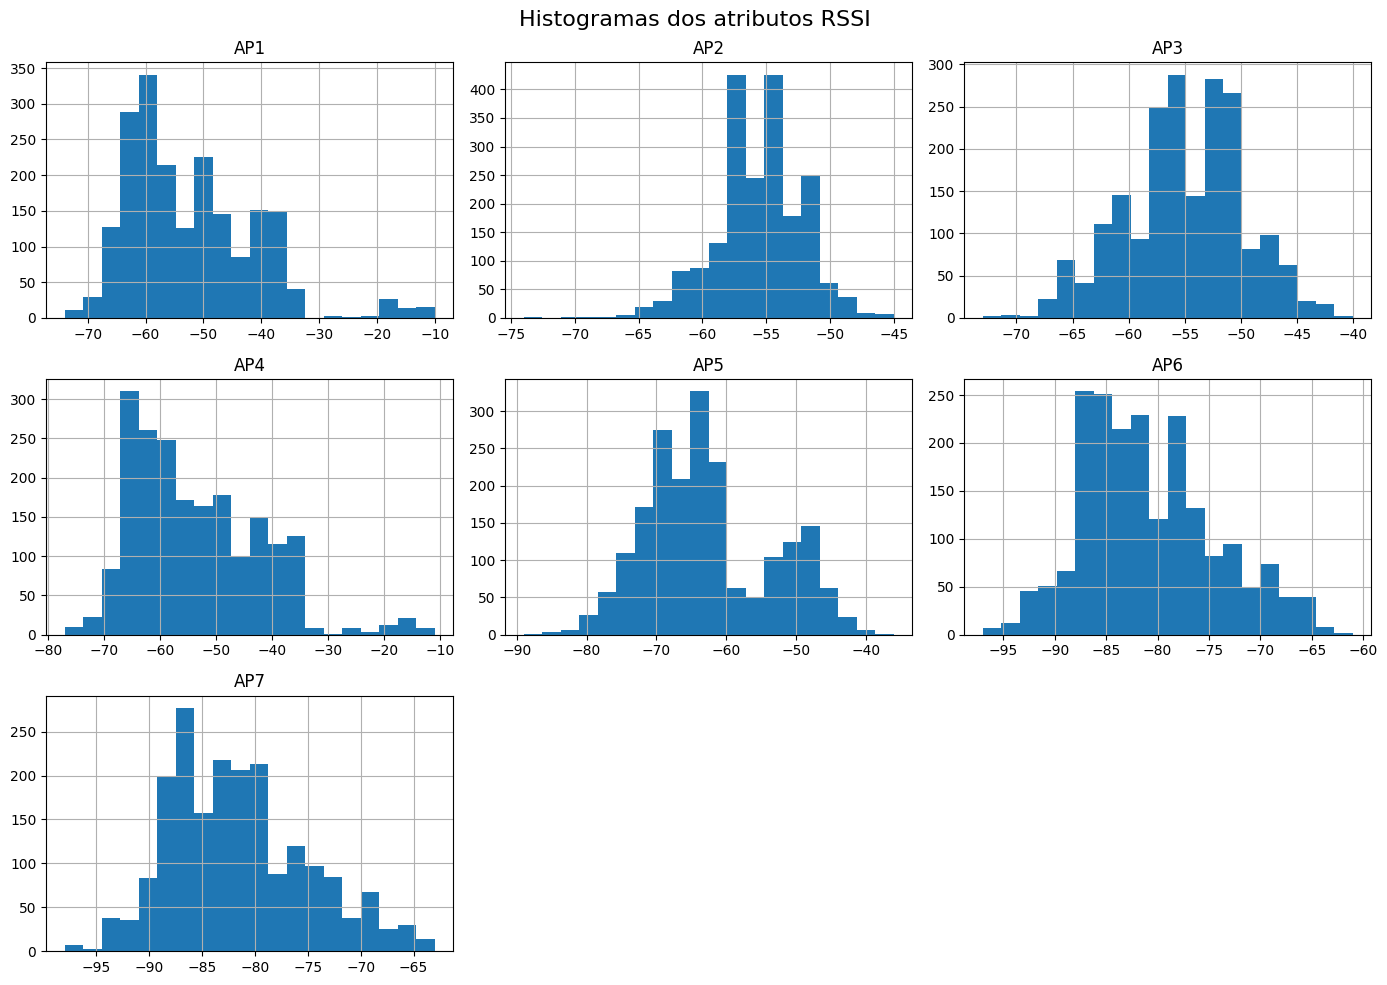

APs com menor dispersão:


,Desvio padrão
AP2,3.417688
AP3,5.316186


APs com maior dispersão:


,Desvio padrão
AP1,11.321677
AP4,11.471982


In [16]:
df[feature_names].hist(bins=20, figsize=(14, 10))
plt.suptitle("Histogramas dos atributos RSSI", fontsize=16)
plt.tight_layout()
plt.show()

std_rssi = df[feature_names].std().sort_values()

mais_concentrados = std_rssi.head(2)
mais_dispersos = std_rssi.tail(2)

print("APs com menor dispersão:")
display(mais_concentrados.to_frame("Desvio padrão"))

print("APs com maior dispersão:")
display(mais_dispersos.to_frame("Desvio padrão"))

Os histogramas mostram a distribuição dos valores de RSSI para cada ponto de acesso.

Atributos com distribuição mais concentrada indicam que o sinal varia pouco entre as amostras. Já atributos com distribuição mais espalhada indicam maior variação de sinal.

Em problemas de localização indoor, essa variação pode ser útil, pois sinais que mudam bastante conforme a sala podem ajudar o modelo a diferenciar melhor os ambientes.

### <font color='#2D9CDB'>Q5) Analise a distribuição das amostras entre as diferentes salas do dataset. Para isso, apresente a quantidade de exemplos pertencentes a cada classe e construa um gráfico de barras mostrando essa distribuição. Em seguida, informe se o conjunto de dados é balanceado e discuta brevemente como o balanceamento das classes pode influenciar o treinamento e a avaliação de modelos de classificação.</font>

,Quantidade de amostras
Room,
1,500
2,500
3,500
4,500


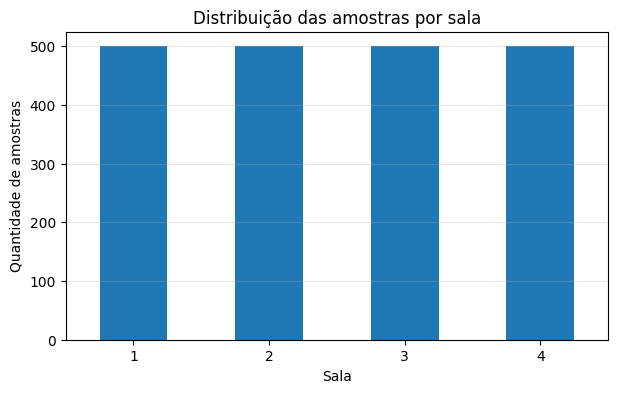

In [17]:
room_counts = df["Room"].value_counts().sort_index()

display(room_counts.to_frame("Quantidade de amostras"))

plt.figure(figsize=(7, 4))
room_counts.plot(kind="bar")
plt.title("Distribuição das amostras por sala")
plt.xlabel("Sala")
plt.ylabel("Quantidade de amostras")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

A distribuição das amostras por sala permite verificar se o dataset está balanceado.

Neste caso, as classes estão bem distribuídas, pois cada sala possui quantidade semelhante ou igual de amostras.

Isso é positivo para o treinamento, porque o modelo não tende a favorecer uma sala apenas por ela possuir mais exemplos. Em datasets desbalanceados, o classificador poderia apresentar boa acurácia geral, mas errar mais nas classes com menos amostras.

### <font color='#2D9CDB'>Q6) Divida o dataset em conjuntos de treinamento e teste utilizando 70% das amostras para treinamento e 30% para teste. Utilize estratificação para preservar a proporção das classes em ambos os conjuntos. Em seguida, informe a quantidade de amostras presente em cada conjunto e verifique se a distribuição das classes foi mantida após a divisão.</font>

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Amostras de treinamento: {X_train.shape[0]}")
print(f"Amostras de teste: {X_test.shape[0]}")

train_dist = pd.Series(y_train, name="Room").value_counts().sort_index()
test_dist = pd.Series(y_test, name="Room").value_counts().sort_index()

dist_df = pd.DataFrame({
    "Treino": train_dist,
    "Teste": test_dist,
    "Proporção treino (%)": (train_dist / train_dist.sum() * 100).round(2),
    "Proporção teste (%)": (test_dist / test_dist.sum() * 100).round(2)
})

display(dist_df)

Amostras de treinamento: 1400
Amostras de teste: 600


,Treino,Teste,Proporção treino (%),Proporção teste (%)
Room,,,,
1,350,150,25.0,25.0
2,350,150,25.0,25.0
3,350,150,25.0,25.0
4,350,150,25.0,25.0


O dataset foi dividido em **70% para treinamento** e **30% para teste**.

Foi usado o parâmetro `stratify=y`, que preserva a proporção das classes nos dois conjuntos. Isso é importante porque garante que todas as salas estejam representadas de forma equilibrada tanto no treino quanto no teste.

Com isso, a avaliação do modelo fica mais justa e menos dependente de uma divisão aleatória desfavorável.

# <font color='green'><u><b>Parte 2 - Árvore de Decisão</b></u></font>

### <font color='#2D9CDB'>Q7) Treine uma árvore de decisão para classificar as salas do dataset utilizando os dados de treinamento. Em seguida, informe a profundidade da árvore, o número de nós folha e apresente uma visualização da estrutura aprendida pelo modelo. Com base na árvore obtida, identifique qual atributo foi utilizado no nó raiz e discuta brevemente o que isso indica sobre sua importância para o processo de classificação.</font>

Profundidade da árvore: 13
Número de nós folha: 37
Atributo usado no nó raiz: AP1


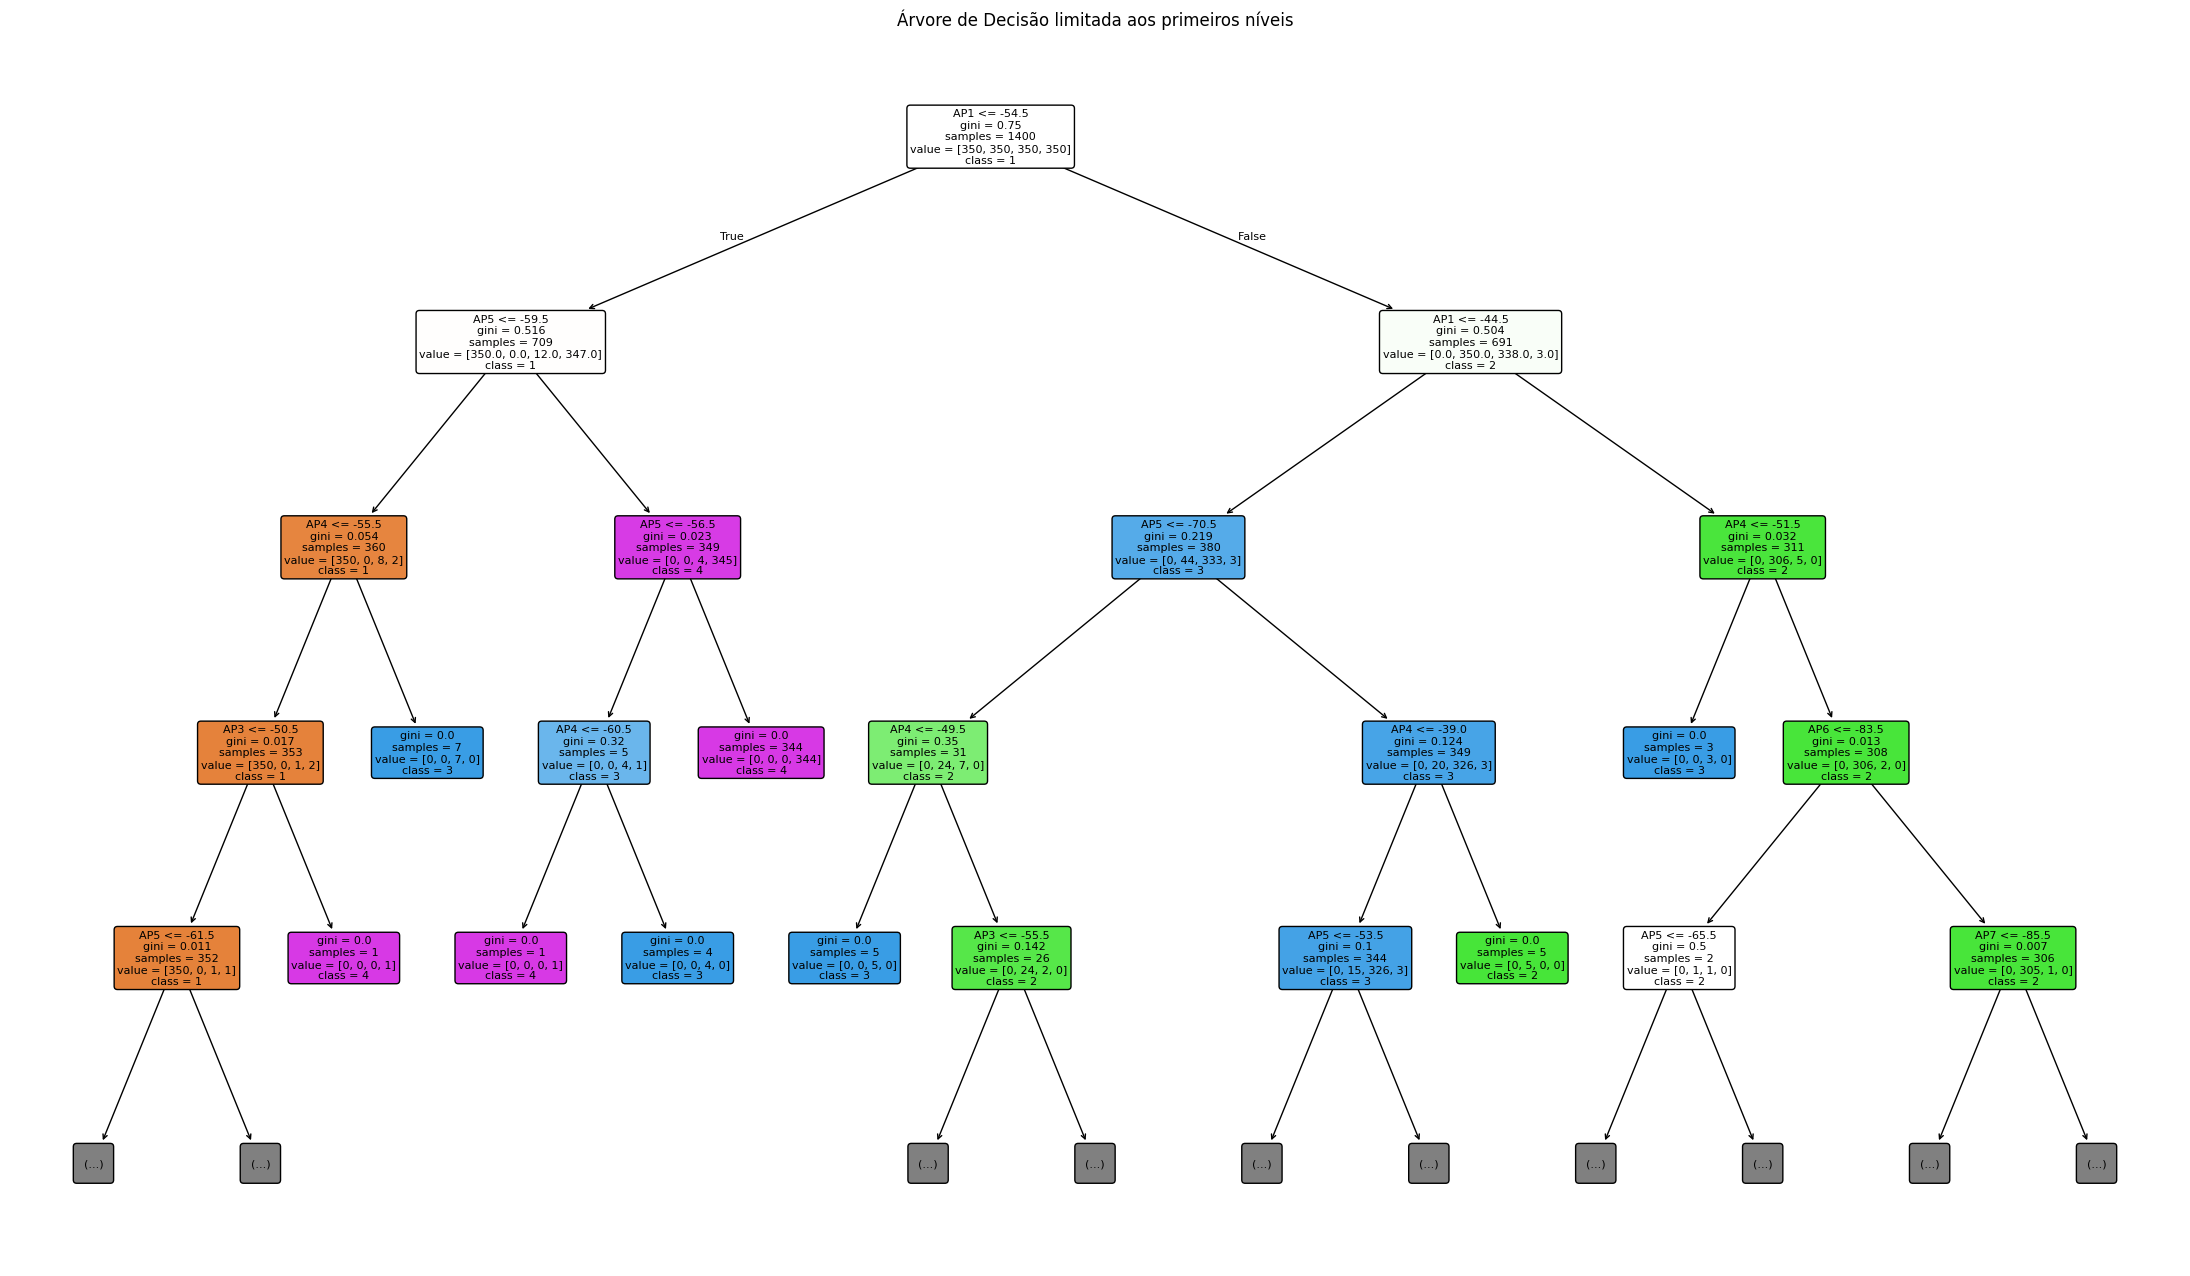

In [19]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

tree_depth = tree.get_depth()
tree_leaves = tree.get_n_leaves()

root_feature_idx = tree.tree_.feature[0]
root_feature = feature_names[root_feature_idx]

print(f"Profundidade da árvore: {tree_depth}")
print(f"Número de nós folha: {tree_leaves}")
print(f"Atributo usado no nó raiz: {root_feature}")

plt.figure(figsize=(28, 16))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=[str(c) for c in np.sort(np.unique(y))],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title("Árvore de Decisão limitada aos primeiros níveis")
plt.show()

A árvore de decisão cria regras baseadas nos valores de RSSI para separar as amostras entre as salas.

O atributo escolhido no nó raiz é considerado o mais importante para a primeira divisão dos dados, pois é usado antes de qualquer outro atributo. Isso indica que esse ponto de acesso possui grande capacidade inicial de separação entre as classes.

A profundidade da árvore indica quantos níveis de decisão foram criados, enquanto o número de folhas representa as decisões finais possíveis da árvore.

### <font color='#2D9CDB'>Q8) Utilize a árvore de decisão treinada para realizar predições sobre o conjunto de teste. Em seguida, calcule a acurácia do modelo e apresente a matriz de confusão correspondente. Com base nos resultados obtidos, analise o desempenho do classificador e identifique quais salas foram classificadas com maior e menor precisão.</font>

Acurácia no conjunto de teste: 0.9733
Acurácia percentual: 97.33%


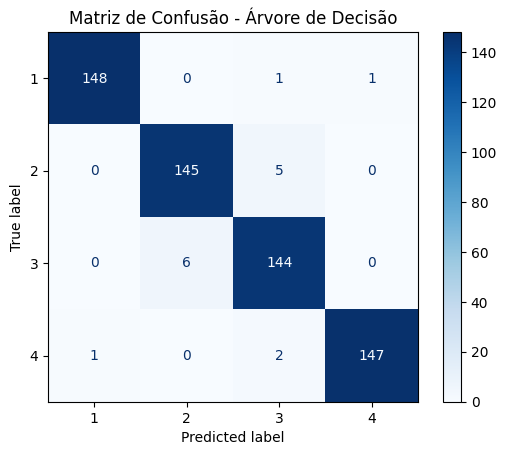

,precision,recall,f1-score,support
1,0.993289,0.986667,0.989967,150.000000
2,0.960265,0.966667,0.963455,150.000000
3,0.947368,0.960000,0.953642,150.000000
4,0.993243,0.980000,0.986577,150.000000
accuracy,0.973333,0.973333,0.973333,0.973333
macro avg,0.973541,0.973333,0.973410,600.000000
weighted avg,0.973541,0.973333,0.973410,600.000000


Sala com maior precisão: 1 (0.9933)
Sala com menor precisão: 3 (0.9474)


In [20]:
y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Acurácia no conjunto de teste: {acc:.4f}")
print(f"Acurácia percentual: {acc * 100:.2f}%")

labels = np.sort(np.unique(y))

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T

display(report_df)

class_rows = [str(c) for c in labels]
precisions = report_df.loc[class_rows, "precision"]

best_room = precisions.idxmax()
worst_room = precisions.idxmin()

print(f"Sala com maior precisão: {best_room} ({precisions.max():.4f})")
print(f"Sala com menor precisão: {worst_room} ({precisions.min():.4f})")

A acurácia mede a proporção de amostras classificadas corretamente no conjunto de teste.

A matriz de confusão permite observar em quais salas o modelo acertou e em quais salas houve confusão. Os valores da diagonal principal representam os acertos. Quanto maior a concentração dos valores nessa diagonal, melhor o desempenho do classificador.

A precisão por classe mostra, entre as amostras previstas como determinada sala, quantas realmente pertenciam àquela sala. Assim, a sala com maior precisão foi a mais confiável nas previsões, enquanto a sala com menor precisão teve mais confusões com outras classes.

### <font color='#2D9CDB'>Q9) Treine novas árvores de decisão limitando a profundidade máxima (`max_depth`) aos valores de 1 a 15. Para cada modelo, calcule a acurácia nos conjuntos de treinamento e teste. Em seguida, organize os resultados em uma tabela e construa um gráfico comparando as acurácias obtidas. Com base nos resultados, analise como a profundidade influencia a complexidade e o desempenho do modelo. Por fim, identifique se há evidências de sobreajuste e indique qual profundidade parece oferecer o melhor equilíbrio entre capacidade de aprendizado e generalização.</font>

In [21]:
depth_results = []

for depth in range(1, 16):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    depth_results.append({
        "max_depth": depth,
        "Acurácia treino": train_acc,
        "Acurácia teste": test_acc
    })

depth_df = pd.DataFrame(depth_results)

display(depth_df)

,max_depth,Acurácia treino,Acurácia teste
0,1,0.500000,0.500000
1,2,0.952857,0.963333
2,3,0.974286,0.970000
3,4,0.982857,0.973333
4,5,0.985714,0.976667
5,6,0.989286,0.973333
6,7,0.990714,0.978333
7,8,0.992143,0.976667
8,9,0.992143,0.980000
9,10,0.994286,0.975000


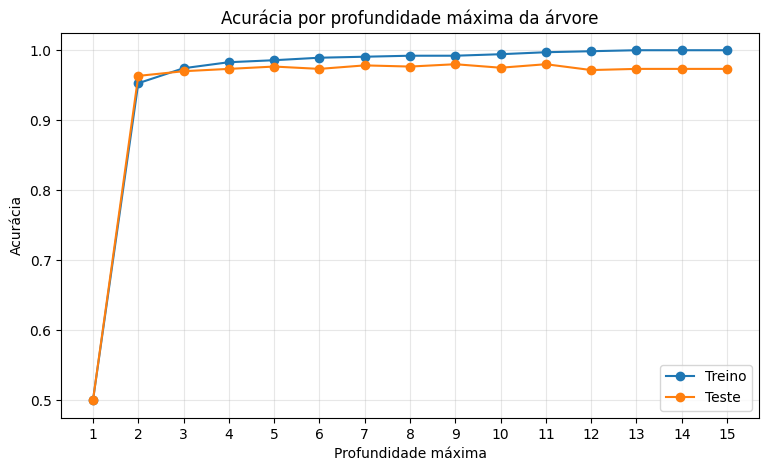

Melhor profundidade: 9
Acurácia de treino: 0.9921
Acurácia de teste: 0.9800


In [22]:
plt.figure(figsize=(9, 5))
plt.plot(depth_df["max_depth"], depth_df["Acurácia treino"], marker="o", label="Treino")
plt.plot(depth_df["max_depth"], depth_df["Acurácia teste"], marker="o", label="Teste")
plt.title("Acurácia por profundidade máxima da árvore")
plt.xlabel("Profundidade máxima")
plt.ylabel("Acurácia")
plt.xticks(range(1, 16))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

best_row = depth_df.sort_values(
    ["Acurácia teste", "max_depth"],
    ascending=[False, True]
).iloc[0]

best_depth = int(best_row["max_depth"])

print(f"Melhor profundidade: {best_depth}")
print(f"Acurácia de treino: {best_row['Acurácia treino']:.4f}")
print(f"Acurácia de teste: {best_row['Acurácia teste']:.4f}")

A profundidade máxima controla a complexidade da árvore de decisão.

Quando a profundidade é muito pequena, a árvore pode ficar simples demais e não capturar bem os padrões dos dados, causando **subajuste**. Quando a profundidade é muito alta, a árvore pode memorizar detalhes do conjunto de treinamento, causando **sobreajuste**.

O melhor valor de profundidade é aquele que apresenta boa acurácia no teste sem depender excessivamente da acurácia no treino. Assim, busca-se um equilíbrio entre desempenho e capacidade de generalização.

### <font color='#2D9CDB'>Q10) Utilizando a árvore de decisão treinada, obtenha a importância de cada atributo RSSI por meio da propriedade `feature_importances_`. Em seguida, construa um gráfico de barras ordenando os atributos do mais importante para o menos importante. Com base nos resultados, identifique quais pontos de acesso contribuíram mais para a classificação das salas e discuta por que alguns atributos podem ser mais relevantes do que outros para o problema de localização indoor.</font>

,Importância
AP1,0.562765
AP5,0.365961
AP4,0.038710
AP7,0.012060
AP3,0.008612
AP6,0.007260
AP2,0.004632


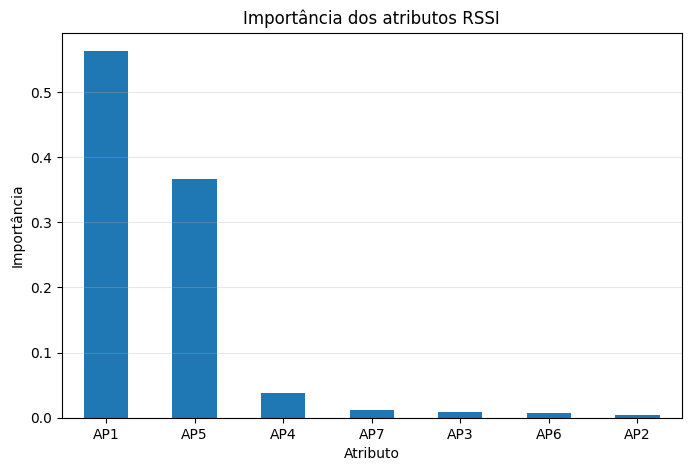

Dois atributos mais importantes: ['AP1', 'AP5']


In [23]:
importances = pd.Series(
    tree.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

display(importances.to_frame("Importância"))

plt.figure(figsize=(8, 5))
importances.plot(kind="bar")
plt.title("Importância dos atributos RSSI")
plt.xlabel("Atributo")
plt.ylabel("Importância")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

top_features = importances.head(2).index.tolist()

print(f"Dois atributos mais importantes: {top_features}")

A importância dos atributos mostra quais pontos de acesso mais contribuíram para as decisões da árvore.

Os atributos com maior importância foram aqueles que mais ajudaram a reduzir a impureza das divisões, separando melhor as salas.

Em localização indoor, alguns pontos de acesso são mais relevantes porque seus sinais variam de forma mais clara entre diferentes ambientes. Por isso, eles acabam sendo mais úteis para identificar a sala correta.

# <font color='green'><u><b>Parte 3 - K-Means</b></u></font>

### <font color='#2D9CDB'>Q11) Diferentemente das árvores de decisão, o algoritmo k-Means não utiliza rótulos durante o treinamento. Pesquise brevemente sobre esse método e descreva, em um único parágrafo, o que é clusterização, qual é o objetivo do algoritmo k-Means, o significado de um centroide e como o algoritmo utiliza a distância entre as amostras para formar agrupamentos.</font>

Clusterização é uma técnica de aprendizado não supervisionado cujo objetivo é organizar amostras em grupos de acordo com sua similaridade, sem utilizar rótulos durante o treinamento.

O algoritmo **k-Means** divide os dados em `k` grupos. Cada grupo possui um centro chamado **centroide**, que representa a posição média das amostras daquele cluster.

O funcionamento básico do k-Means ocorre em etapas:

1. Escolhe-se o número de clusters `k`;
2. O algoritmo inicializa os centroides;
3. Cada amostra é associada ao centroide mais próximo;
4. Os centroides são recalculados com base nas amostras atribuídas a cada grupo;
5. O processo se repete até que os agrupamentos fiquem estáveis.

No contexto de localização indoor, o k-Means pode ser usado para tentar descobrir grupos naturais de medições Wi-Fi, mesmo sem saber previamente a sala real de cada amostra.

### <font color='#2D9CDB'>Q12) Considere os dois atributos mais importantes identificados na Q10. Construa um gráfico de dispersão utilizando essas variáveis, representando as amostras de cada sala com cores distintas e uma legenda apropriada. Com base na visualização obtida, analise a distribuição das amostras e discuta se existem agrupamentos naturais nos dados. Na sua opinião, seria possível identificar as diferentes salas sem utilizar os rótulos originais?</font>

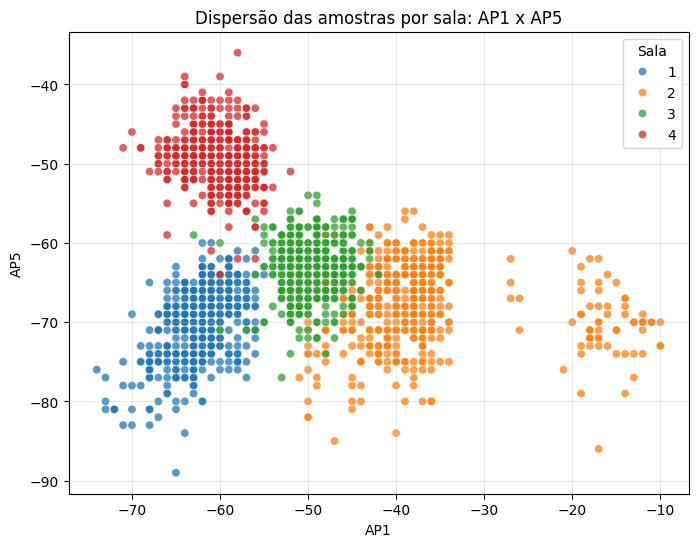

In [24]:
feat1, feat2 = top_features

plot_df = df[[feat1, feat2, "Room"]].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x=feat1,
    y=feat2,
    hue="Room",
    palette="tab10",
    alpha=0.75
)
plt.title(f"Dispersão das amostras por sala: {feat1} x {feat2}")
plt.xlabel(feat1)
plt.ylabel(feat2)
plt.legend(title="Sala")
plt.grid(alpha=0.3)
plt.show()

O gráfico de dispersão mostra as amostras usando os dois atributos mais importantes encontrados pela árvore de decisão.

Quando pontos da mesma sala aparecem próximos entre si e separados dos pontos de outras salas, há indícios de agrupamentos naturais. Isso significa que esses dois atributos conseguem representar bem parte da diferença entre os ambientes.

Porém, se houver sobreposição entre pontos de salas diferentes, o processo de clusterização pode apresentar confusão, pois o k-Means não usa os rótulos reais das salas durante o treinamento.

### <font color='#2D9CDB'>Q13) Antes de aplicar o algoritmo k-Means, é necessário definir o número de clusters (*k*). Utilize o Método do Cotovelo (Elbow Method) para avaliar valores de *k* entre 1 e 10. Para cada valor, calcule a inércia do modelo e construa um gráfico relacionando o número de clusters e a inércia obtida. Com base no gráfico, identifique o valor de *k* que parece mais adequado para este conjunto de dados e justifique sua escolha.</font>

In [25]:
kmeans_features = ["AP1", "AP5"]
X_kmeans = df[kmeans_features].values

inertias = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_kmeans)
    inertias.append(km.inertia_)

elbow_df = pd.DataFrame({
    "k": range(1, 11),
    "Inércia": inertias
})

display(elbow_df)

,k,Inércia
0,1,421955.059000
1,2,236935.229513
2,3,131404.029077
3,4,81710.249491
4,5,54722.154324
5,6,46219.673414
6,7,37950.811395
7,8,33705.287852
8,9,29628.051664
9,10,27525.313047


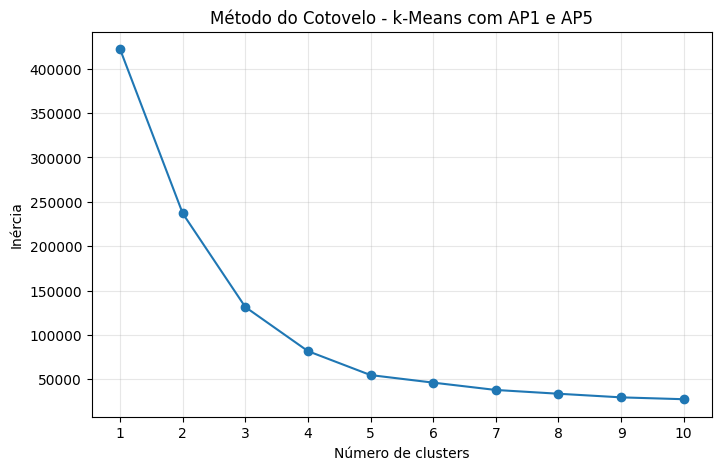

k escolhido: 4


In [26]:
plt.figure(figsize=(8, 5))
plt.plot(elbow_df["k"], elbow_df["Inércia"], marker="o")
plt.title("Método do Cotovelo - k-Means com AP1 e AP5")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

k_escolhido = 4

print(f"k escolhido: {k_escolhido}")

O método do cotovelo é usado para escolher um valor adequado de `k` no k-Means.

A inércia mede a soma das distâncias das amostras até seus respectivos centroides. Conforme o número de clusters aumenta, a inércia tende a diminuir. Porém, depois de certo ponto, essa redução passa a ser menos significativa.

O valor escolhido foi **k = 4**, pois o dataset possui quatro salas reais e esse valor também é compatível com a ideia de procurar quatro agrupamentos principais nos dados.

### <font color='#2D9CDB'>Q14) Utilizando o valor de *k* identificado na Q13, treine um modelo k-Means empregando apenas os atributos AP1 e AP5. Em seguida, apresente as coordenadas dos centroides encontrados e construa um gráfico de dispersão mostrando as amostras coloridas de acordo com o cluster atribuído pelo algoritmo. Destaque também os centroides no gráfico. Com base nos resultados, analise a qualidade dos agrupamentos obtidos.</font>

In [27]:
kmeans_ap1_ap5 = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
clusters_ap1_ap5 = kmeans_ap1_ap5.fit_predict(X_kmeans)

centroids_ap1_ap5 = pd.DataFrame(
    kmeans_ap1_ap5.cluster_centers_,
    columns=kmeans_features
)

centroids_ap1_ap5.index.name = "Cluster"

display(centroids_ap1_ap5)

,AP1,AP5
Cluster,,
0,-60.207243,-49.372233
1,-34.801008,-67.821159
2,-62.377470,-70.424901
3,-48.931667,-63.638333


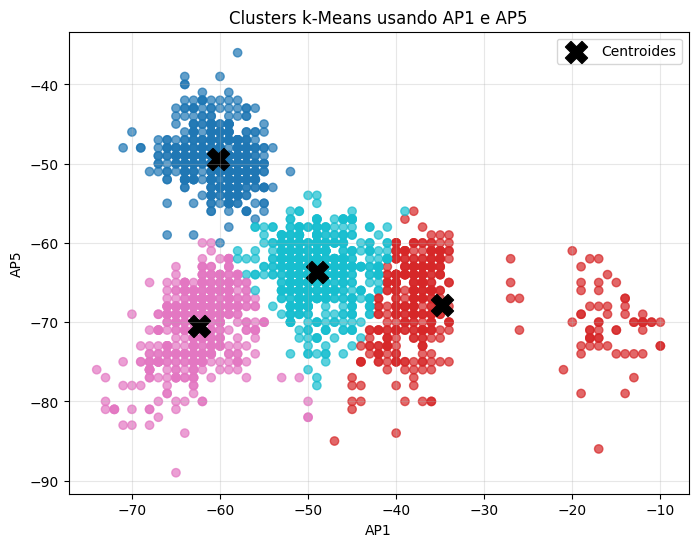

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_kmeans[:, 0],
    X_kmeans[:, 1],
    c=clusters_ap1_ap5,
    cmap="tab10",
    alpha=0.7
)
plt.scatter(
    kmeans_ap1_ap5.cluster_centers_[:, 0],
    kmeans_ap1_ap5.cluster_centers_[:, 1],
    marker="X",
    s=250,
    c="black",
    label="Centroides"
)
plt.title("Clusters k-Means usando AP1 e AP5")
plt.xlabel("AP1")
plt.ylabel("AP5")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

O k-Means foi aplicado usando os atributos `AP1` e `AP5`.

Os centroides representam os pontos centrais de cada cluster no espaço formado por esses dois atributos. Cada amostra foi associada ao centroide mais próximo.

Os agrupamentos indicam regiões com padrões semelhantes de RSSI. Como foram usados apenas dois atributos, pode existir sobreposição entre salas diferentes, principalmente se os sinais de `AP1` e `AP5` forem parecidos em alguns ambientes.

### <font color='#2D9CDB'>Q15) Compare os clusters encontrados pelo k-Means com as salas reais do dataset. Para isso, construa uma <a href="https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html">tabela de contingência</a> relacionando cada sala aos clusters atribuídos pelo algoritmo. Em seguida, identifique qual cluster representa predominantemente cada sala e calcule a porcentagem de amostras associadas a esse agrupamento. Com base nos resultados, discuta quais salas foram mais facilmente identificadas pelo algoritmo e quais apresentaram maior grau de confusão com outros grupos.</font>

In [29]:
comparison_df = df[["Room"]].copy()
comparison_df["Cluster"] = clusters_ap1_ap5

contingency = pd.crosstab(
    comparison_df["Room"],
    comparison_df["Cluster"]
)

display(contingency)

predominant = contingency.idxmax(axis=1)
percent_predominant = (
    contingency.max(axis=1) / contingency.sum(axis=1) * 100
).round(2)

summary_clusters = pd.DataFrame({
    "Cluster predominante": predominant,
    "Porcentagem no cluster predominante (%)": percent_predominant
})

display(summary_clusters)

Cluster,0,1,2,3
Room,,,,
1,0,0,493,7
2,0,396,4,100
3,3,0,7,490
4,494,0,2,4


,Cluster predominante,Porcentagem no cluster predominante (%)
Room,,
1,2,98.6
2,1,79.2
3,3,98.0
4,0,98.8


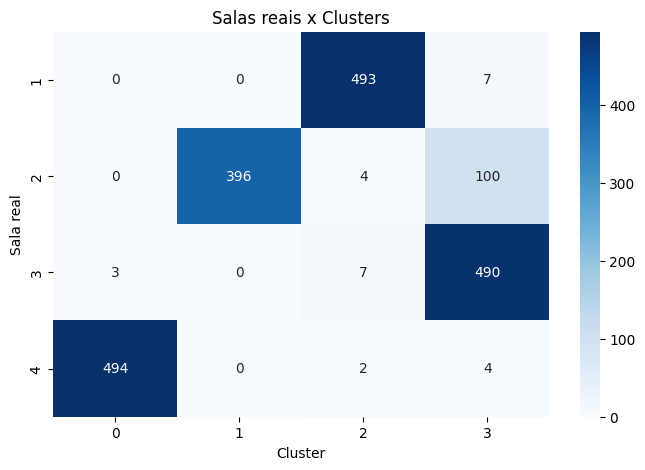

In [30]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    contingency,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Salas reais x Clusters")
plt.xlabel("Cluster")
plt.ylabel("Sala real")
plt.show()

A tabela de contingência compara as salas reais com os clusters encontrados pelo k-Means.

Se uma sala aparece concentrada principalmente em um único cluster, isso indica que o k-Means conseguiu representar bem aquela sala usando os atributos escolhidos.

Por outro lado, se as amostras de uma mesma sala aparecem espalhadas em vários clusters, significa que há maior confusão. Isso pode acontecer porque o k-Means não conhece os rótulos reais e trabalha apenas com a proximidade dos pontos no espaço dos atributos.

# <font color='green'><u><b>Parte 4 - Detecção de Anomalias</b></u></font>

### <font color='#2D9CDB'>Q16) Uma aplicação comum de algoritmos de clusterização é a detecção de anomalias. Em geral, amostras localizadas muito longe do centroide de seu cluster podem representar comportamentos incomuns ou situações atípicas. Utilizando os dois atributos mais importantes identificados na Q10, calcule a distância euclidiana de cada amostra ao centroide do cluster ao qual ela foi atribuída pelo k-Means. Em seguida, apresente um histograma dessas distâncias e informe os valores mínimo, máximo, médio e o desvio padrão observados. Com base nos resultados, discuta o que essas distâncias revelam sobre a compactação dos clusters encontrados.</font>

,Distância ao centroide
count,2000.000000
mean,5.235470
std,3.667657
min,0.267549
25%,2.953891
50%,4.511155
75%,6.503792
max,25.442998


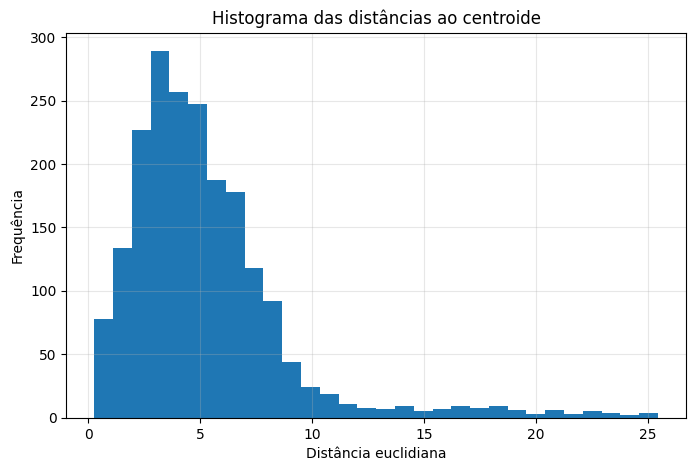

Atributos usados: ['AP1', 'AP5']
Distância mínima: 0.2675
Distância máxima: 25.4430
Distância média: 5.2355
Desvio padrão: 3.6667


In [31]:
anom_features = top_features
X_anom = df[anom_features].values

kmeans_anom = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
clusters_anom = kmeans_anom.fit_predict(X_anom)

centroids_anom = kmeans_anom.cluster_centers_

distances = np.linalg.norm(
    X_anom - centroids_anom[clusters_anom],
    axis=1
)

distance_stats = pd.Series(distances).describe()

display(distance_stats.to_frame("Distância ao centroide"))

plt.figure(figsize=(8, 5))
plt.hist(distances, bins=30)
plt.title("Histograma das distâncias ao centroide")
plt.xlabel("Distância euclidiana")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

print(f"Atributos usados: {anom_features}")
print(f"Distância mínima: {distances.min():.4f}")
print(f"Distância máxima: {distances.max():.4f}")
print(f"Distância média: {distances.mean():.4f}")
print(f"Desvio padrão: {distances.std():.4f}")

A distância de cada amostra até o centroide de seu cluster pode ser usada como uma medida de normalidade.

Amostras próximas ao centroide representam comportamentos mais comuns dentro daquele grupo. Já amostras muito distantes do centroide podem indicar padrões incomuns ou possíveis anomalias.

Esse método é simples e útil para detectar medições que fogem do padrão esperado dos sinais Wi-Fi.

### <font color='#2D9CDB'>Q17) Considere que amostras muito distantes do centroide de seu cluster podem ser classificadas como potenciais anomalias. Utilize o percentil de 95% das distâncias calculadas na Q16 como limiar de detecção. Em seguida, identifique todas as amostras cuja distância ao centroide seja superior a esse valor, informe quantas anomalias foram encontradas e apresente as cinco amostras mais distantes de seus respectivos centroides. Com base nos resultados, discuta se o critério adotado parece adequado para identificar observações atípicas.</font>

In [32]:
threshold_95 = np.percentile(distances, 95)

anomaly_mask = distances > threshold_95

anomalies_df = df.copy()
anomalies_df["Cluster"] = clusters_anom
anomalies_df["Distância ao centroide"] = distances
anomalies_df["Anomalia"] = anomaly_mask

In [33]:
anomalias = anomalies_df[anomalies_df["Anomalia"]].sort_values(
    "Distância ao centroide",
    ascending=False
)

print(f"Limiar percentil 95%: {threshold_95:.4f}")
print(f"Quantidade de anomalias encontradas: {len(anomalias)}")

display(anomalias.head(10))

Limiar percentil 95%: 11.6104
Quantidade de anomalias encontradas: 100


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room,Cluster,Distância ao centroide,Anomalia
609,-17,-63,-65,-27,-86,-72,-74,2,1,25.442998,True
769,-10,-57,-57,-36,-73,-82,-72,2,1,25.335950,True
873,-10,-58,-62,-20,-73,-76,-74,2,1,25.335950,True
870,-10,-58,-54,-18,-70,-72,-73,2,1,24.896532,True
932,-11,-59,-60,-27,-70,-74,-71,2,1,23.900529,True
869,-11,-63,-65,-18,-70,-72,-73,2,1,23.900529,True
858,-13,-54,-57,-21,-77,-72,-72,2,1,23.654493,True
607,-12,-60,-68,-15,-74,-73,-70,2,1,23.623379,True
604,-14,-59,-64,-16,-79,-76,-72,2,1,23.614580,True
539,-12,-60,-62,-14,-71,-77,-71,2,1,23.021533,True


Foi usado o percentil 95% como limiar para detectar anomalias.

Isso significa que aproximadamente os 5% pontos mais distantes dos seus centroides foram considerados anômalos. Esses pontos representam medições menos comuns em relação ao padrão médio do cluster ao qual pertencem.

Esse critério é útil como primeira abordagem, mas não garante que todas as amostras marcadas sejam erros. Algumas podem ser apenas medições raras, porém ainda válidas.

### <font color='#2D9CDB'>Q18) Construa um gráfico de dispersão utilizando os dois atributos empregados pelo k-Means e destaque as anomalias identificadas na Q17. Represente também os centroides dos clusters. Com base na visualização obtida, avalie se as amostras classificadas como anômalas encontram-se em regiões afastadas dos centroides e discuta se os resultados são coerentes com o critério de detecção adotado.</font>

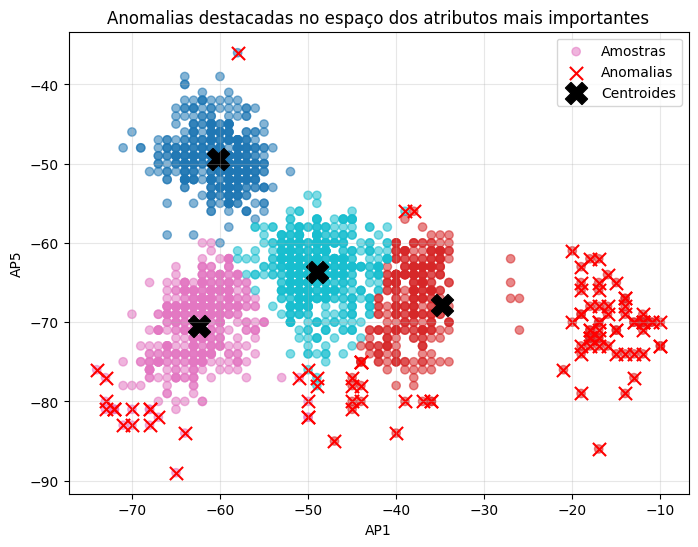

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_anom[:, 0],
    X_anom[:, 1],
    c=clusters_anom,
    cmap="tab10",
    alpha=0.55,
    label="Amostras"
)

plt.scatter(
    X_anom[anomaly_mask, 0],
    X_anom[anomaly_mask, 1],
    c="red",
    marker="x",
    s=90,
    label="Anomalias"
)

plt.scatter(
    centroids_anom[:, 0],
    centroids_anom[:, 1],
    c="black",
    marker="X",
    s=250,
    label="Centroides"
)

plt.title("Anomalias destacadas no espaço dos atributos mais importantes")
plt.xlabel(anom_features[0])
plt.ylabel(anom_features[1])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

O gráfico mostra as amostras, os centroides e os pontos classificados como anomalias.

As anomalias aparecem destacadas porque possuem distância maior em relação ao centroide do cluster ao qual foram associadas.

Visualmente, é esperado que essas amostras estejam mais afastadas das regiões centrais dos grupos. Isso confirma a lógica do método utilizado, que considera mais suspeitos os pontos distantes do comportamento médio do cluster.

### <font color='#2D9CDB'>Q19) O limiar utilizado para detectar anomalias influencia diretamente a quantidade de observações classificadas como atípicas. Repita o procedimento da Q17 utilizando os percentis 90%, 95% e 99% das distâncias aos centroides. Para cada caso, registre o valor do limiar e o número de anomalias detectadas. Organize os resultados em uma tabela e discuta como a escolha do percentil afeta a sensibilidade do detector de anomalias.</font>

In [35]:
percentiles = [90, 95, 99]

threshold_results = []

for p in percentiles:
    threshold = np.percentile(distances, p)
    n_anomalies = int((distances > threshold).sum())

    threshold_results.append({
        "Percentil": p,
        "Limiar": threshold,
        "Anomalias detectadas": n_anomalies,
        "Percentual aproximado (%)": round(n_anomalies / len(distances) * 100, 2)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Percentil,Limiar,Anomalias detectadas,Percentual aproximado (%)
0,90,8.577111,200,10.0
1,95,11.610351,100,5.0
2,99,20.817381,20,1.0


A escolha do percentil altera diretamente a quantidade de anomalias detectadas.

Com percentil 90%, o limiar é menor, então mais amostras são classificadas como anômalas. Esse caso é mais sensível, mas pode gerar mais falsos positivos.

Com percentil 95%, há um equilíbrio intermediário, marcando apenas os pontos mais distantes.

Com percentil 99%, o limiar é mais alto, então apenas os casos extremamente distantes são classificados como anomalias. Esse critério é mais conservador, mas pode deixar de detectar alguns pontos suspeitos.

# <font color='green'><u><b>Parte 5 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q20) Ao longo desta atividade foram exploradas técnicas de aprendizado supervisionado (Árvores de Decisão) e não supervisionado (k-Means), além de uma abordagem simples para detecção de anomalias baseada na distância aos centroides. Compare essas três aplicações quanto aos seus objetivos, à utilização de rótulos durante o treinamento, aos resultados produzidos e às situações em que cada uma delas é mais adequada. Por fim, discuta como essas técnicas poderiam ser utilizadas em conjunto em um sistema de localização indoor baseado em sinais Wi-Fi.</font>

A **árvore de decisão** é uma técnica de aprendizado supervisionado. Ela usa os rótulos reais das salas durante o treinamento e aprende regras para classificar novas amostras. Sua principal vantagem é a interpretabilidade, pois é possível visualizar quais atributos foram usados nas decisões.

O **k-Means** é uma técnica de aprendizado não supervisionado. Ele não usa os rótulos das salas e tenta encontrar grupos naturais nos dados com base na similaridade entre as amostras. No contexto de localização indoor, ele pode ajudar a entender se os padrões de RSSI formam agrupamentos parecidos com as salas reais.

A **detecção de anomalias por distância ao centroide** usa os clusters encontrados pelo k-Means para identificar amostras muito distantes do padrão médio de seu grupo. Essas amostras podem representar ruídos, medições incomuns ou situações que merecem análise adicional.

Em um sistema real de localização indoor por Wi-Fi, essas técnicas poderiam ser combinadas da seguinte forma: a árvore de decisão faria a classificação direta da sala, o k-Means ajudaria a explorar os agrupamentos naturais dos sinais, e a detecção de anomalias indicaria medições suspeitas que poderiam ser revisadas antes da decisão final.